In [274]:
import pandas as pd
from sqlalchemy import (
    create_engine,
    Column,
    Integer,
    String,
    inspect,
    ForeignKey,
    text,
    select,
    func,
    or_,
)
from sqlalchemy.orm import declarative_base, relationship, sessionmaker
from create_db import config_local
from create_db.data_classes import Player, PlayerStat, MVPCandidate, MVPWinner, AdvancedStat, PlayerStat, TeamPerformance, Roster, SeasonStat, Team
import cryptography
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import utilities as util
import numpy as np
from scipy import stats
from importlib import reload

Gettin data from database

In [275]:
plt.rcParams["figure.dpi"] = 270
sns.set_theme(style="white")
warnings.filterwarnings(
    "ignore", message="Glyph .* missing from font", category=UserWarning
)


In [276]:
###setting up the engine
DB_USER, DB_PASSWORD, DB_HOST, DB_PORT, DB_NAME = (
    config_local.DB_USER,
    config_local.DB_PASSWORD,
    config_local.DB_HOST,
    config_local.DB_PORT,
    config_local.DB_NAME,
)


Base = declarative_base()
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True,
)
SessionLocal = sessionmaker(bind=engine)
session = SessionLocal()

insp = inspect(engine)

In [277]:
for model in (Player, PlayerStat, MVPCandidate, MVPWinner, AdvancedStat, PlayerStat, TeamPerformance, Roster, SeasonStat, Team):
    mapper = inspect(model)
    print (model.__tablename__)
    print (mapper.columns.keys())
    print ("relationships:", mapper.relationships.keys() )
    print ("-"*25)


players
['player_id', 'player_name', 'shoots', 'draft_team_name', 'experience', 'nba_debut', 'position_1', 'position_2', 'position_3', 'position_4', 'position_5', 'position_6', 'draft_year', 'height_cm', 'weight_kg', 'age', 'draft_round_pick_rank', 'draft_overall_pick_rank', 'career_points', 'career_total_rebound_pct', 'career_assists_pct', 'career_field_goal_pct', 'career_three_point_pct', 'career_free_throw_pct', 'career_effective_fg_pct', 'career_per', 'career_win_shares']
relationships: ['playerstats', 'mvp_finishes', 'mvp_titles', 'rosters', 'advanced_stats']
-------------------------
player_stats
['season', 'player_id', 'rank', 'age', 'team_id', 'position', 'games_played', 'games_started', 'minutes_played', 'field_goals_made', 'field_goals_attempted', 'field_goal_pct', 'three_pointers_made', 'three_pointers_attempted', 'three_point_pct', 'two_pointers_made', 'two_pointers_attempted', 'two_point_pct', 'effective_fg_pct', 'free_throws_made', 'free_throws_attempted', 'free_throw_pct

In [278]:
with session:
    stmt = (
        select(
            Player.player_id,
            Player.player_name,
            Player.age,
            Player.experience,
            Player.draft_overall_pick_rank,
            func.sum(PlayerStat.triple_doubles).label('triple_doubles'),
            func.avg(AdvancedStat.player_efficiency_rate).label('average_efficiency_rate'),
            func.sum(AdvancedStat.win_shares).label('total_win_shares'),
            func.avg(AdvancedStat.total_rebound_percentage).label('average_rebound_percentage'),
            func.avg(AdvancedStat.assist_percentage).label('average_assist_percentage'),
            func.avg(AdvancedStat.steal_percentage).label('average_steal_percentage'),
            func.avg(AdvancedStat.block_percentage).label('average_block_percentage'),
            func.sum(AdvancedStat.offensive_box_plus_minus).label('total_offensive_box_plus_minus'),
            func.sum(AdvancedStat.defensive_box_plus_minus).label('total_defensive_box_plus_minus'),
            func.sum(AdvancedStat.value_over_replacement_player).label('total_value_over_replacement_player'),

            
            )
        .join(Player.playerstats)
        
        .join(
            AdvancedStat,
            (AdvancedStat.player_id == PlayerStat.player_id)
            & (AdvancedStat.season == PlayerStat.season),
        
        )
        .filter( 
            Player.draft_overall_pick_rank != None ,
            Player.draft_overall_pick_rank <= 10,

        )
        .order_by(func.sum(PlayerStat.triple_doubles).desc())
        .group_by(Player.player_id)

    )
    BestPicks_df = pd.read_sql(stmt, session.get_bind() )


### Question: 
### Trade Target Analysis: Draft Pick Strategy

The team manager has concluded that, due to a streak of misfortune, the franchise is unlikely to secure the **No. 1 overall draft pick** in the foreseeable future.  

Following his tweet *“Fine, I’ll do it myself”*, he signaled to fans his intention to pursue a player who had previously been selected as a **No. 1 overall draft pick**.  

However, historical data indicates that **not all No. 1 draft picks have consistently achieved elite performance levels**, and the pool of such players currently available for trade is quite limited.  

As a result, the strategy is adjusted to **expand the target range to players drafted within the Top 10**.  

Our objective is therefore to:
1. Identify the most successful players drafted within picks **1–10** across previous years.  
2. Evaluate their current availability and suitability as **trade candidates**.  
3. Recommend the most optimal player(s) for acquisition based on performance and value.


In [279]:
BestPicks_df.head(10)

,player_id,player_name,age,experience,draft_overall_pick_rank,triple_doubles,average_efficiency_rate,total_win_shares,average_rebound_percentage,average_assist_percentage,average_steal_percentage,average_block_percentage,total_offensive_box_plus_minus,total_defensive_box_plus_minus,total_value_over_replacement_player
0,westbru01,russell westbrook,37.0,17.0,4.0,90.0,19.150000,16.4,13.925000,40.574999,1.900000,0.850000,6.300000,2.5,10.100000
1,doncilu01,luka donÃ¤ÂiÃ¤Â,26.0,7.0,3.0,82.0,25.500000,57.1,13.557143,41.442857,1.757143,1.142857,44.900000,8.1,38.300000
2,jamesle01,lebron james,41.0,22.0,1.0,49.0,24.542858,51.9,12.300000,38.885714,1.557143,1.571429,41.700000,8.8,34.000000
3,hardeja01,james harden,36.0,16.0,3.0,40.0,23.950000,59.6,10.050000,38.416667,1.983333,1.833333,34.700000,5.6,32.200001
4,moranja01,ja morant,26.0,6.0,2.0,12.0,20.220000,23.2,7.780000,35.980000,1.560000,0.760000,17.199999,-3.1,11.400000
5,simmobe01,ben simmons,29.0,7.0,1.0,10.0,20.000000,8.2,13.700000,34.200001,2.000000,1.800000,2.200000,1.3,3.800000
6,cunnica01,cade cunningham,24.0,4.0,1.0,9.0,18.850000,7.7,8.400000,40.250000,1.350000,1.500000,5.800000,-1.5,4.900000
7,randlju01,julius randle,31.0,11.0,7.0,8.0,18.600000,34.0,14.666667,20.816667,1.066667,1.016667,11.500000,-0.9,14.100000
8,duranke01,kevin durant,37.0,17.0,2.0,8.0,23.620000,40.2,10.060000,24.320000,1.080000,2.880000,25.700000,1.4,21.100000
9,embiijo01,joel embiid,31.0,9.0,3.0,7.0,29.816666,55.3,19.433333,21.716667,1.450000,4.183333,36.500000,10.5,27.500000


In [280]:
BestPicks_df.info

<bound method DataFrame.info of     player_id        player_name   age  experience  draft_overall_pick_rank  \
0   westbru01  russell westbrook  37.0        17.0                      4.0   
1   doncilu01  luka donÃ¤ÂiÃ¤Â  26.0         7.0                      3.0   
2   jamesle01       lebron james  41.0        22.0                      1.0   
3   hardeja01       james harden  36.0        16.0                      3.0   
4   moranja01          ja morant  26.0         6.0                      2.0   
..        ...                ...   ...         ...                      ...   
59  aldrila01  lamarcus aldridge  40.0         NaN                      2.0   
60  gallida01   danilo gallinari  37.0        14.0                      6.0   
61  gordoaa01       aaron gordon  30.0        11.0                      4.0   
62  castlst01     stephon castle  21.0         1.0                      4.0   
63  sharpsh01     shaedon sharpe  22.0         3.0                      7.0   

    triple_doubles 

In [281]:
BestPicks_df

,player_id,player_name,age,experience,draft_overall_pick_rank,triple_doubles,average_efficiency_rate,total_win_shares,average_rebound_percentage,average_assist_percentage,average_steal_percentage,average_block_percentage,total_offensive_box_plus_minus,total_defensive_box_plus_minus,total_value_over_replacement_player
0,westbru01,russell westbrook,37.0,17.0,4.0,90.0,19.150000,16.4,13.925000,40.574999,1.900000,0.850000,6.300000,2.5,10.100000
1,doncilu01,luka donÃ¤ÂiÃ¤Â,26.0,7.0,3.0,82.0,25.500000,57.1,13.557143,41.442857,1.757143,1.142857,44.900000,8.1,38.300000
2,jamesle01,lebron james,41.0,22.0,1.0,49.0,24.542858,51.9,12.300000,38.885714,1.557143,1.571429,41.700000,8.8,34.000000
3,hardeja01,james harden,36.0,16.0,3.0,40.0,23.950000,59.6,10.050000,38.416667,1.983333,1.833333,34.700000,5.6,32.200001
4,moranja01,ja morant,26.0,6.0,2.0,12.0,20.220000,23.2,7.780000,35.980000,1.560000,0.760000,17.199999,-3.1,11.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,aldrila01,lamarcus aldridge,40.0,NaN,2.0,0.0,22.900000,9.3,15.100000,11.600000,0.800000,3.400000,2.400000,-0.6,2.600000
60,gallida01,danilo gallinari,37.0,14.0,6.0,0.0,20.250000,14.5,10.200000,11.750000,1.100000,0.550000,9.000000,-1.4,5.700000
61,gordoaa01,aaron gordon,30.0,11.0,4.0,0.0,15.100000,5.1,11.700000,16.600000,1.100000,1.800000,0.300000,0.3,1.700000
62,castlst01,stephon castle,21.0,1.0,4.0,0.0,13.700000,1.1,7.400000,22.799999,1.700000,0.900000,-1.500000,-1.7,-0.600000


In [282]:
reload(util)

<module 'utilities' from 'd:\\Quera Bootcamp\\Data Analysis\\Week 8\\3rd mini project\\Data-Analysis-Projects-2-Basketball\\utilities.py'>

In [283]:
util.Get_BestPicks_df_Ready(BestPicks_df)

d:\Quera Bootcamp\Data Analysis\Week 8\3rd mini project\Data-Analysis-Projects-2-Basketball\utilities.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [284]:
BestPicks_df

,player_id,player_name,age,experience,draft_overall_pick_rank,triple_doubles,average_efficiency_rate,total_win_shares,average_rebound_percentage,average_assist_percentage,average_steal_percentage,average_block_percentage,total_offensive_box_plus_minus,total_defensive_box_plus_minus,total_value_over_replacement_player,Top5_picks,vorp_tier,age_group,defense_tier,per_reference_guide
0,westbru01,russell westbrook,37.0,17.0,4.0,90.0,19.15,16.4,13.92,40.57,1.90,0.85,6.3,2.5,10.1,1.0,low_vorp,30-40,bad,not_a_starter
1,doncilu01,luka doncic,26.0,7.0,3.0,82.0,25.50,57.1,13.56,41.44,1.76,1.14,44.9,8.1,38.3,1.0,high_vorp,20-30,bad,mvp_candidate
2,jamesle01,lebron james,41.0,22.0,1.0,49.0,24.54,51.9,12.30,38.89,1.56,1.57,41.7,8.8,34.0,1.0,high_vorp,30-40,bad,all-star_candidate
3,hardeja01,james harden,36.0,16.0,3.0,40.0,23.95,59.6,10.05,38.42,1.98,1.83,34.7,5.6,32.2,1.0,high_vorp,30-40,bad,all-star_candidate
4,moranja01,ja morant,26.0,6.0,2.0,12.0,20.22,23.2,7.78,35.98,1.56,0.76,17.2,-3.1,11.4,1.0,low_vorp,20-30,great,all-star_candidate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,aldrila01,lamarcus aldridge,40.0,NaN,2.0,0.0,22.90,9.3,15.10,11.60,0.80,3.40,2.4,-0.6,2.6,1.0,low_vorp,30-40,great,all-star_candidate
60,gallida01,danilo gallinari,37.0,14.0,6.0,0.0,20.25,14.5,10.20,11.75,1.10,0.55,9.0,-1.4,5.7,0.0,low_vorp,30-40,great,all-star_candidate
61,gordoaa01,aaron gordon,30.0,11.0,4.0,0.0,15.10,5.1,11.70,16.60,1.10,1.80,0.3,0.3,1.7,1.0,low_vorp,30-40,bad,not_a_starter
62,castlst01,stephon castle,21.0,1.0,4.0,0.0,13.70,1.1,7.40,22.80,1.70,0.90,-1.5,-1.7,-0.6,1.0,low_vorp,20-30,great,not_a_starter


In [285]:
BestPicks_df.info

<bound method DataFrame.info of     player_id        player_name   age  experience  draft_overall_pick_rank  \
0   westbru01  russell westbrook  37.0        17.0                      4.0   
1   doncilu01        luka doncic  26.0         7.0                      3.0   
2   jamesle01       lebron james  41.0        22.0                      1.0   
3   hardeja01       james harden  36.0        16.0                      3.0   
4   moranja01          ja morant  26.0         6.0                      2.0   
..        ...                ...   ...         ...                      ...   
59  aldrila01  lamarcus aldridge  40.0         NaN                      2.0   
60  gallida01   danilo gallinari  37.0        14.0                      6.0   
61  gordoaa01       aaron gordon  30.0        11.0                      4.0   
62  castlst01     stephon castle  21.0         1.0                      4.0   
63  sharpsh01     shaedon sharpe  22.0         3.0                      7.0   

    triple_doubles 

In [286]:
BestPicks_df.describe

<bound method NDFrame.describe of     player_id        player_name   age  experience  draft_overall_pick_rank  \
0   westbru01  russell westbrook  37.0        17.0                      4.0   
1   doncilu01        luka doncic  26.0         7.0                      3.0   
2   jamesle01       lebron james  41.0        22.0                      1.0   
3   hardeja01       james harden  36.0        16.0                      3.0   
4   moranja01          ja morant  26.0         6.0                      2.0   
..        ...                ...   ...         ...                      ...   
59  aldrila01  lamarcus aldridge  40.0         NaN                      2.0   
60  gallida01   danilo gallinari  37.0        14.0                      6.0   
61  gordoaa01       aaron gordon  30.0        11.0                      4.0   
62  castlst01     stephon castle  21.0         1.0                      4.0   
63  sharpsh01     shaedon sharpe  22.0         3.0                      7.0   

    triple_double

## Plots

c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated

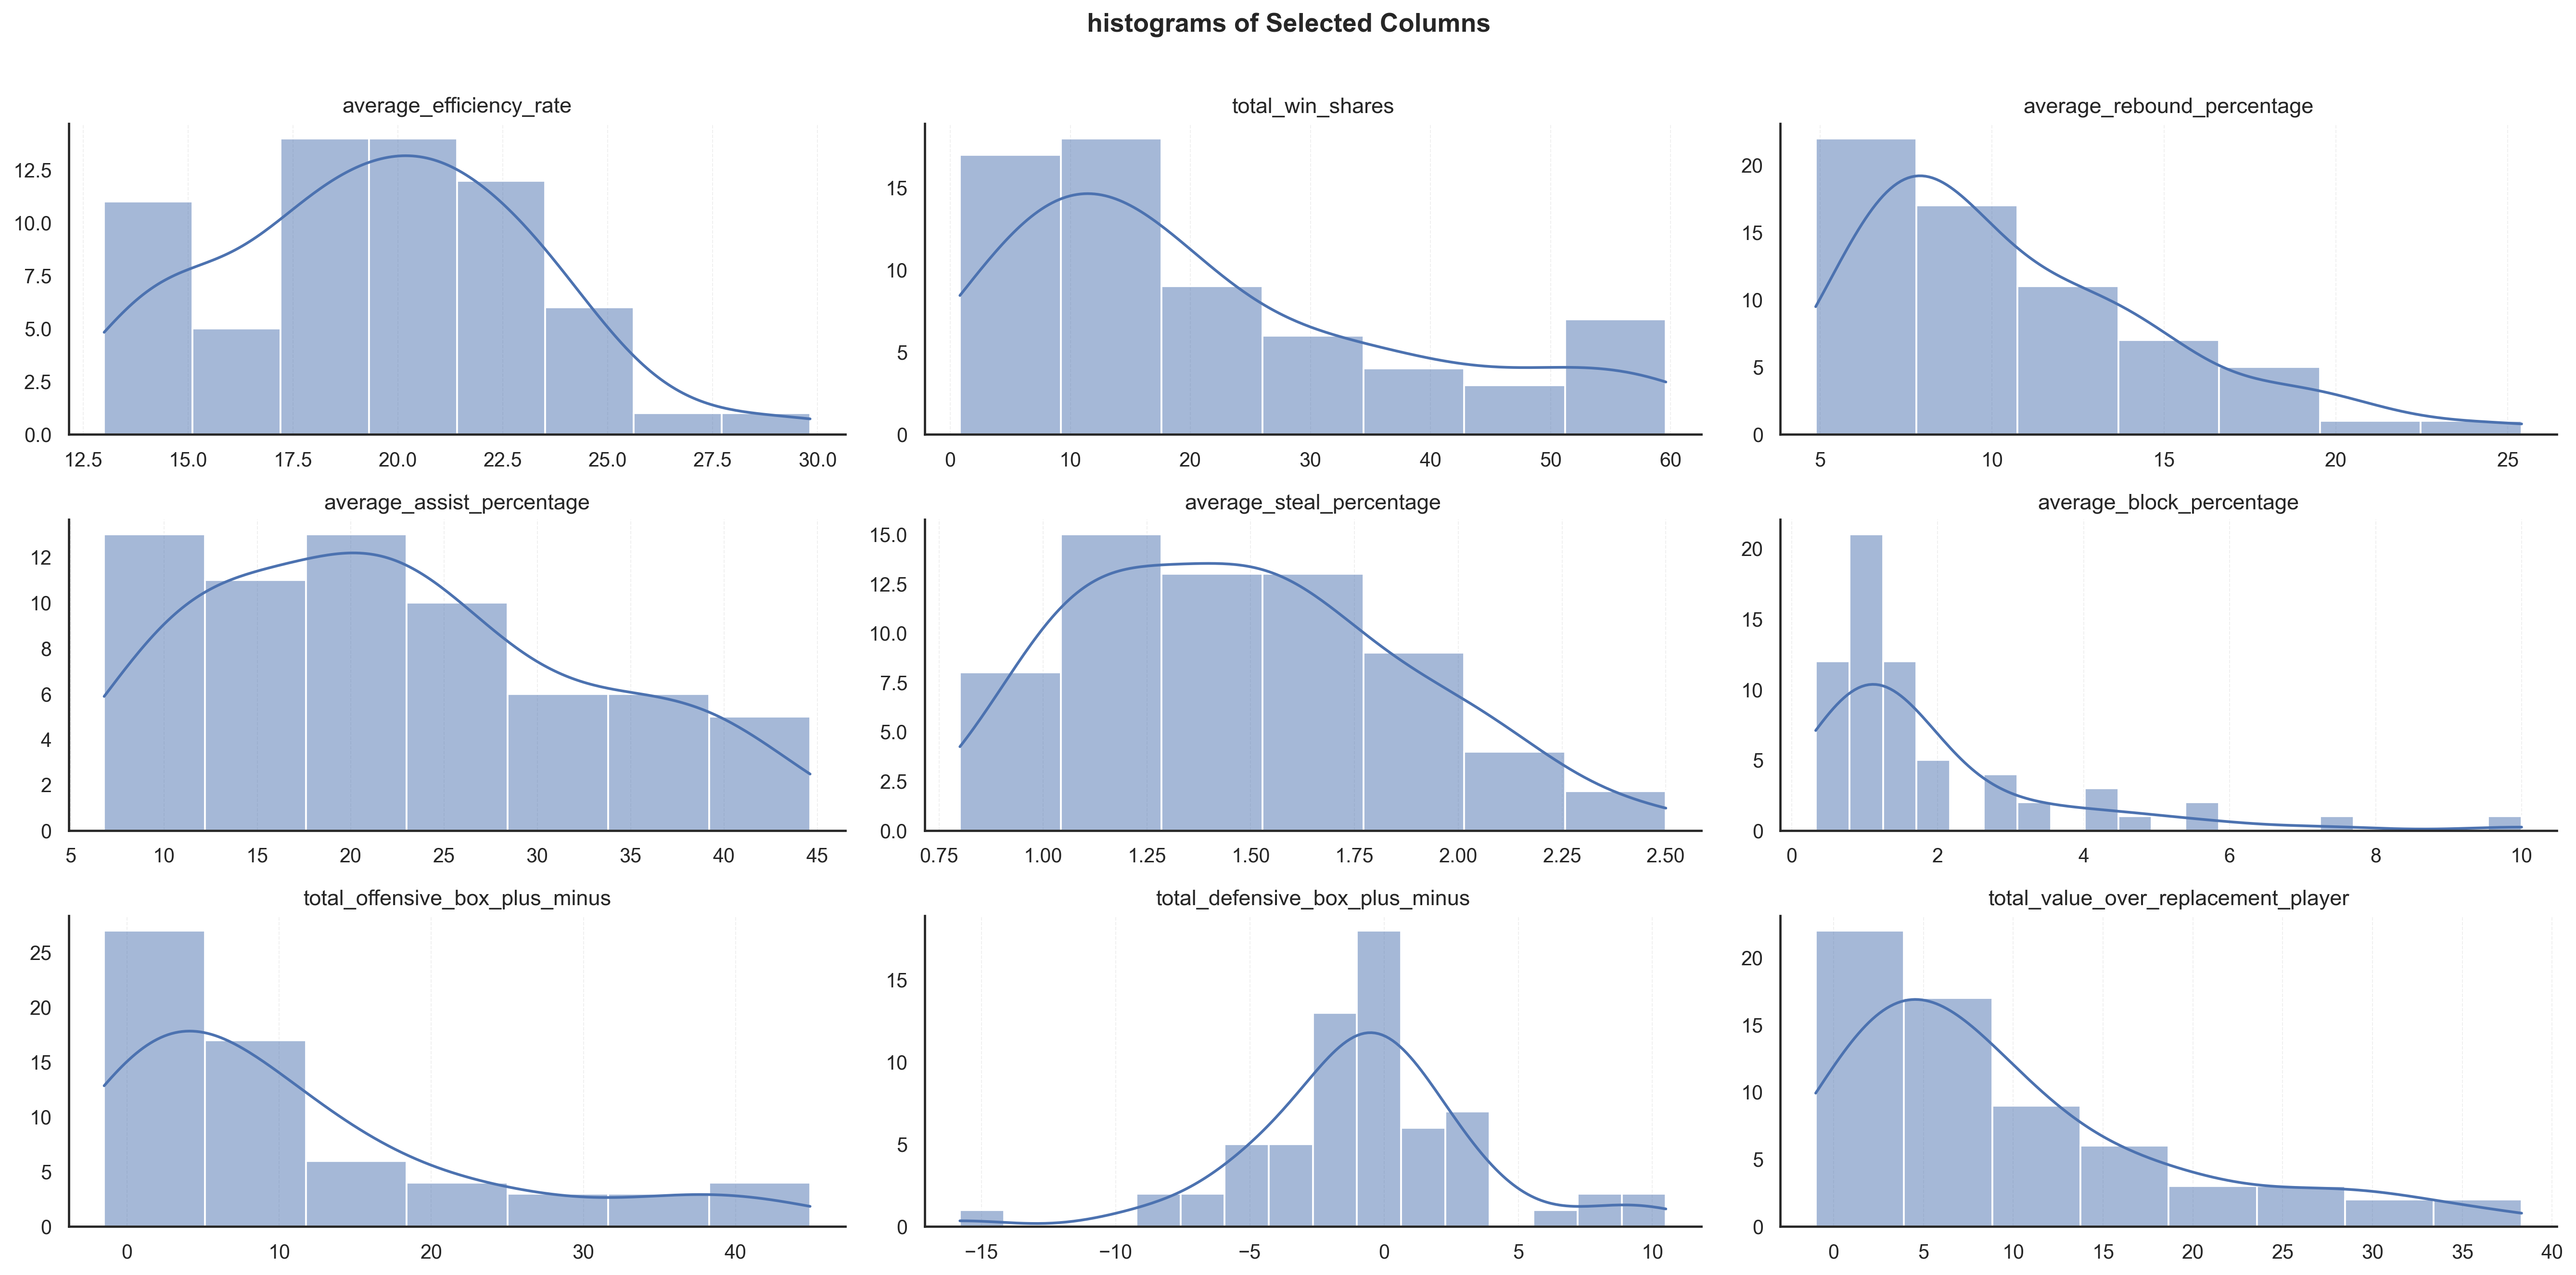

In [287]:
util.hist_plot(continuous_stats , BestPicks_df , 20 ,10)

c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: Fu

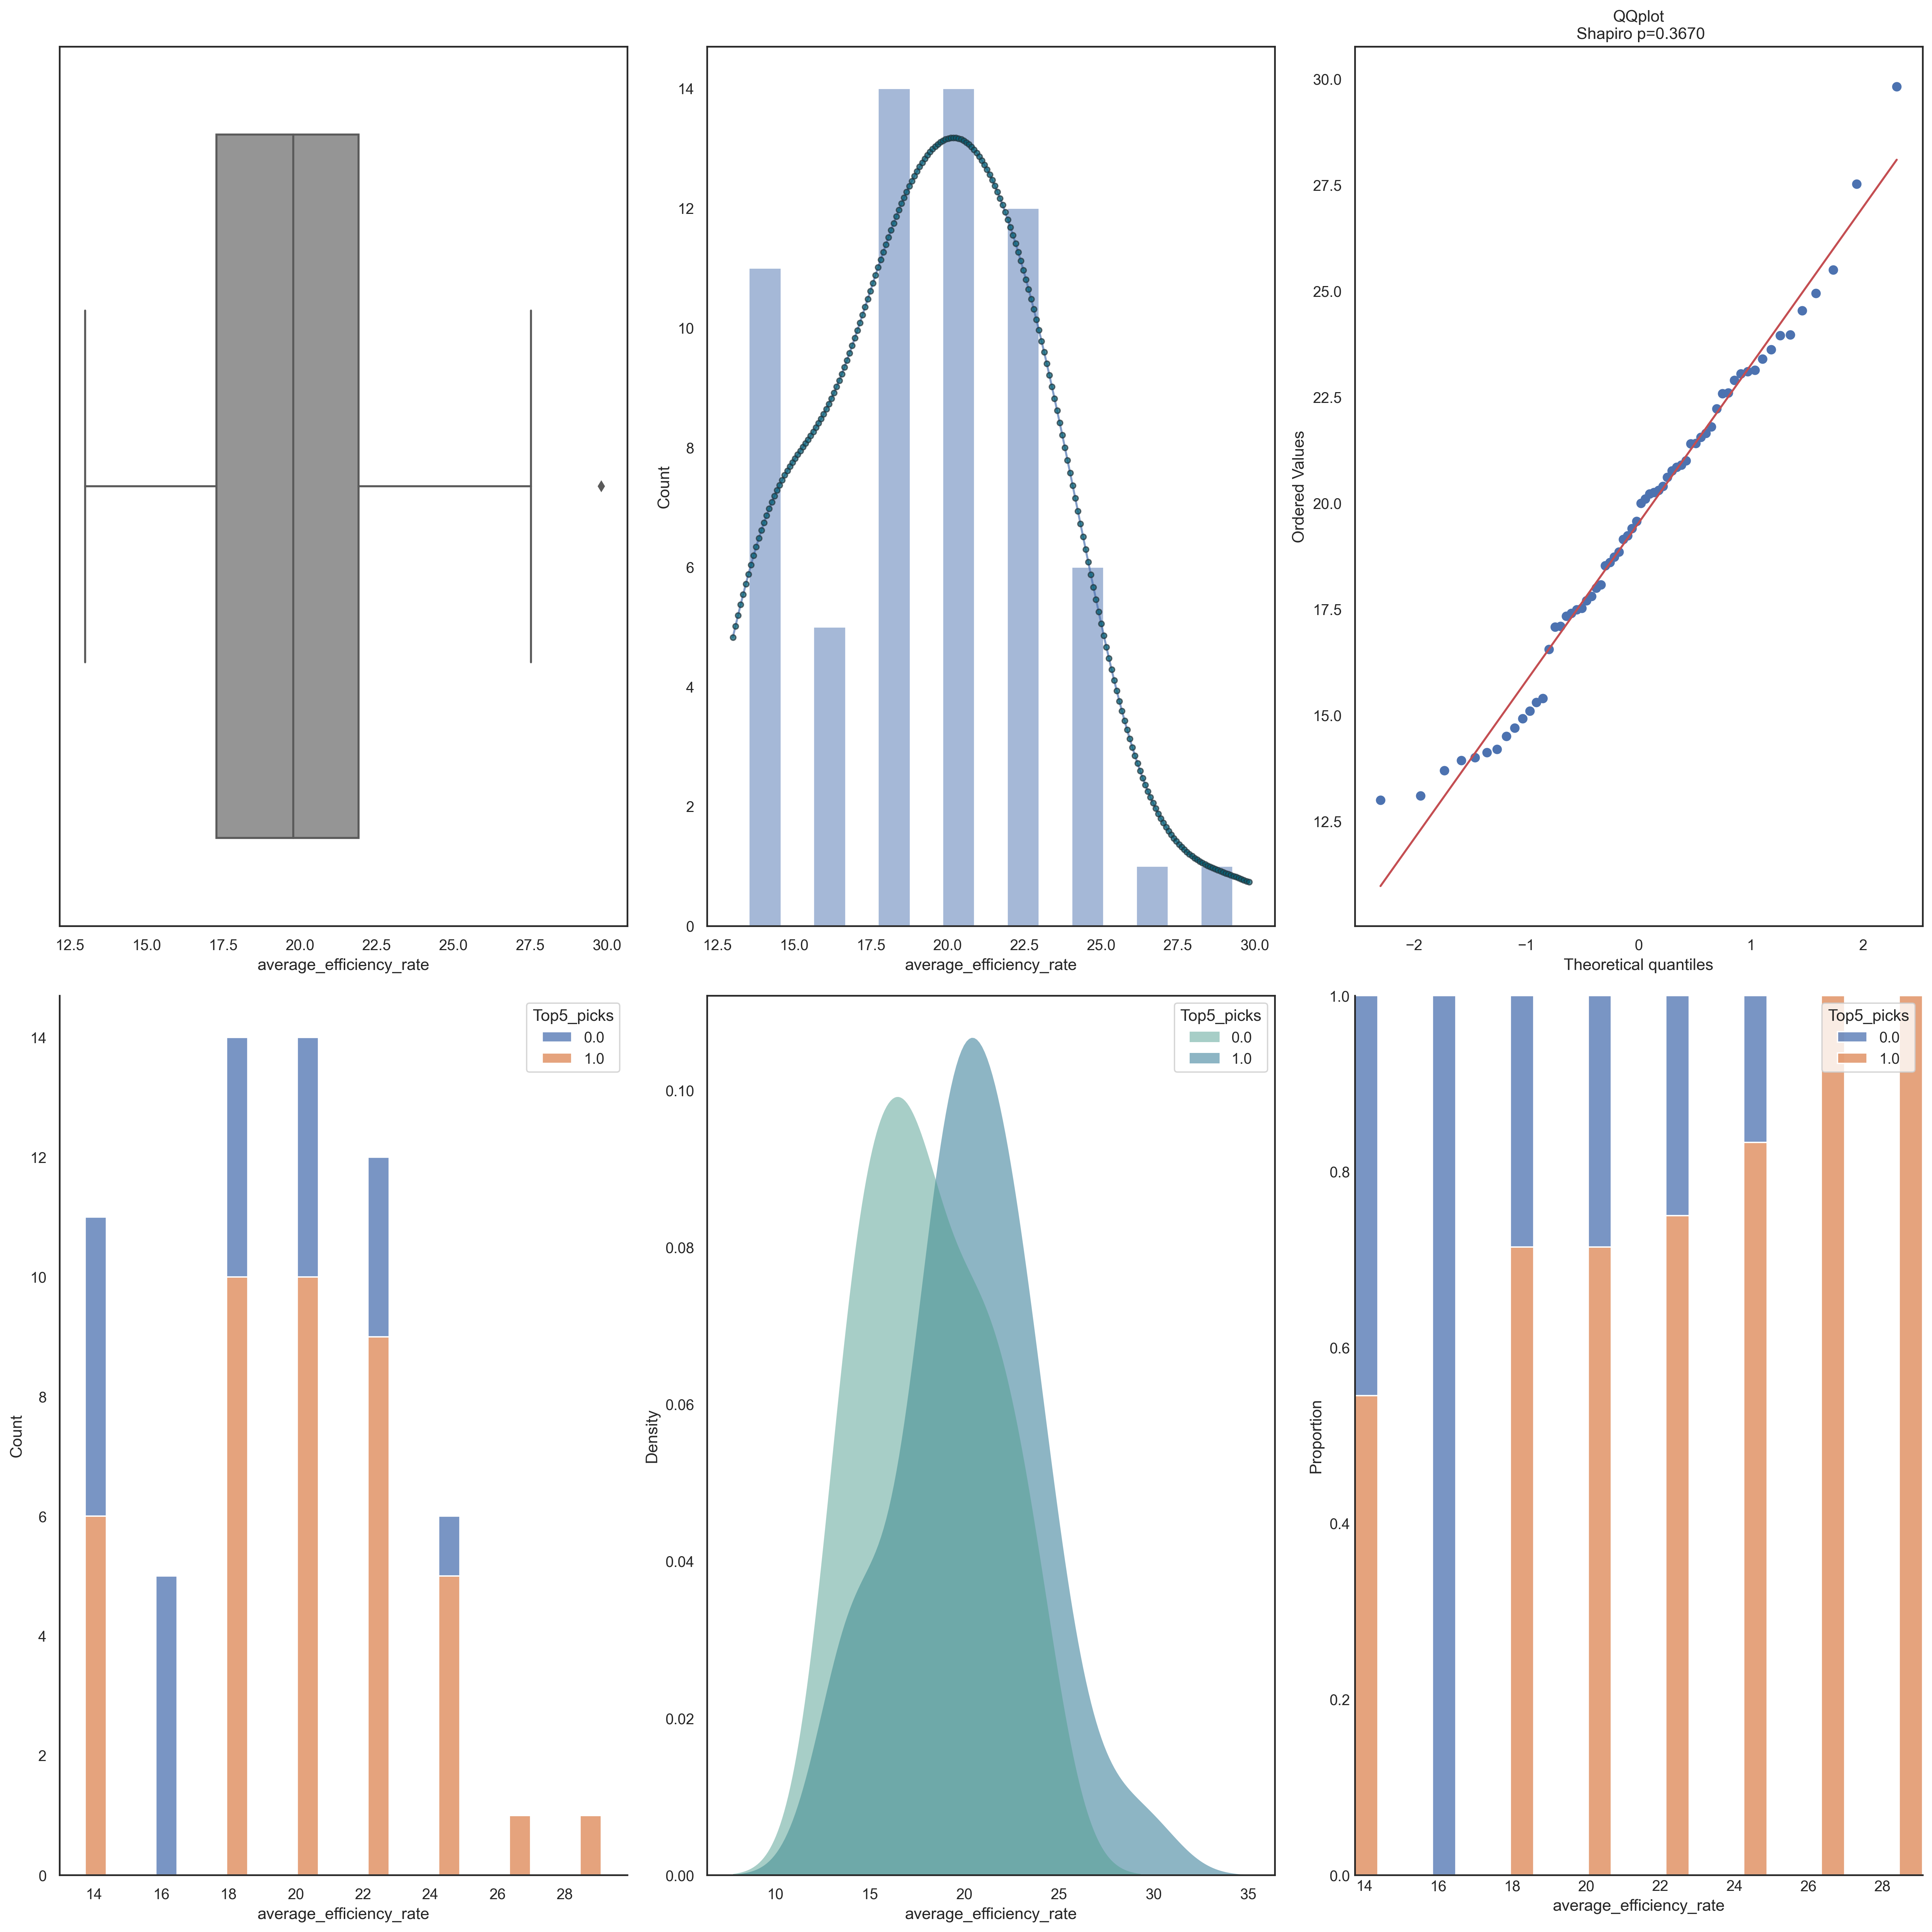

In [288]:
util.continuous_vs_binary(BestPicks_df ,'average_efficiency_rate' , 'Top5_picks')

c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: Fu

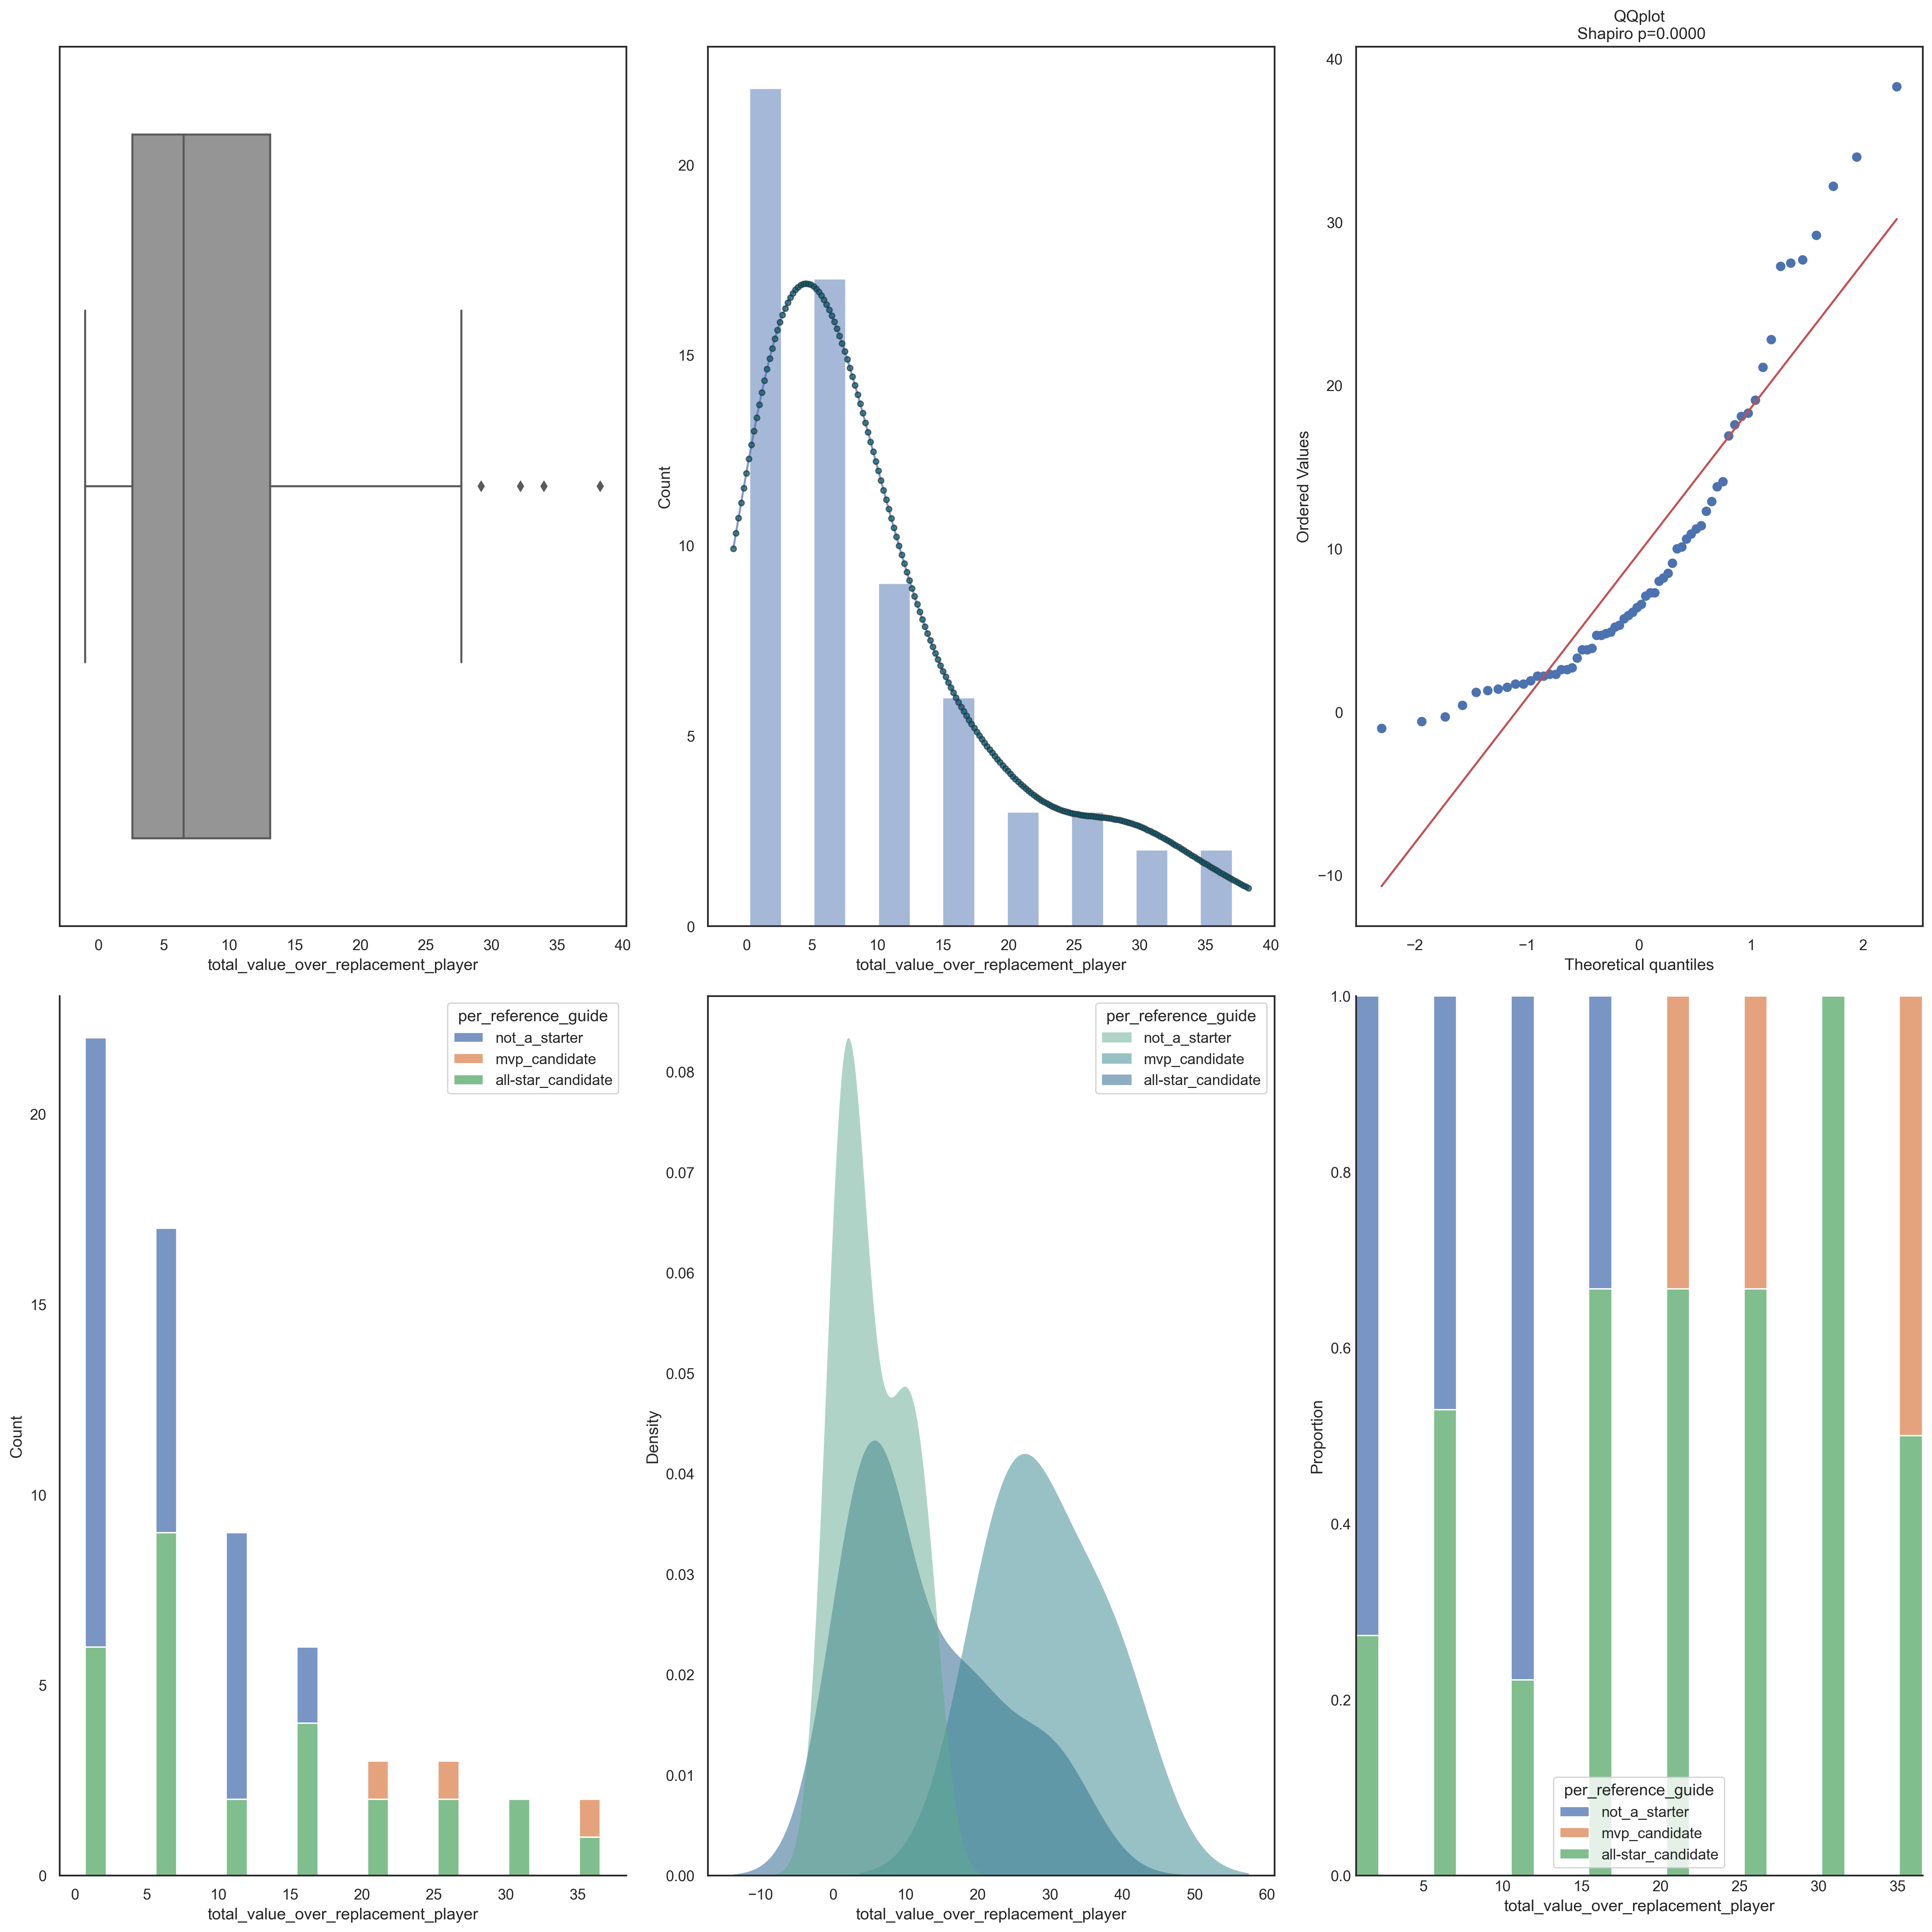

In [289]:
util.continuous_vs_binary(BestPicks_df ,'total_value_over_replacement_player' , 'per_reference_guide')

c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: Fu

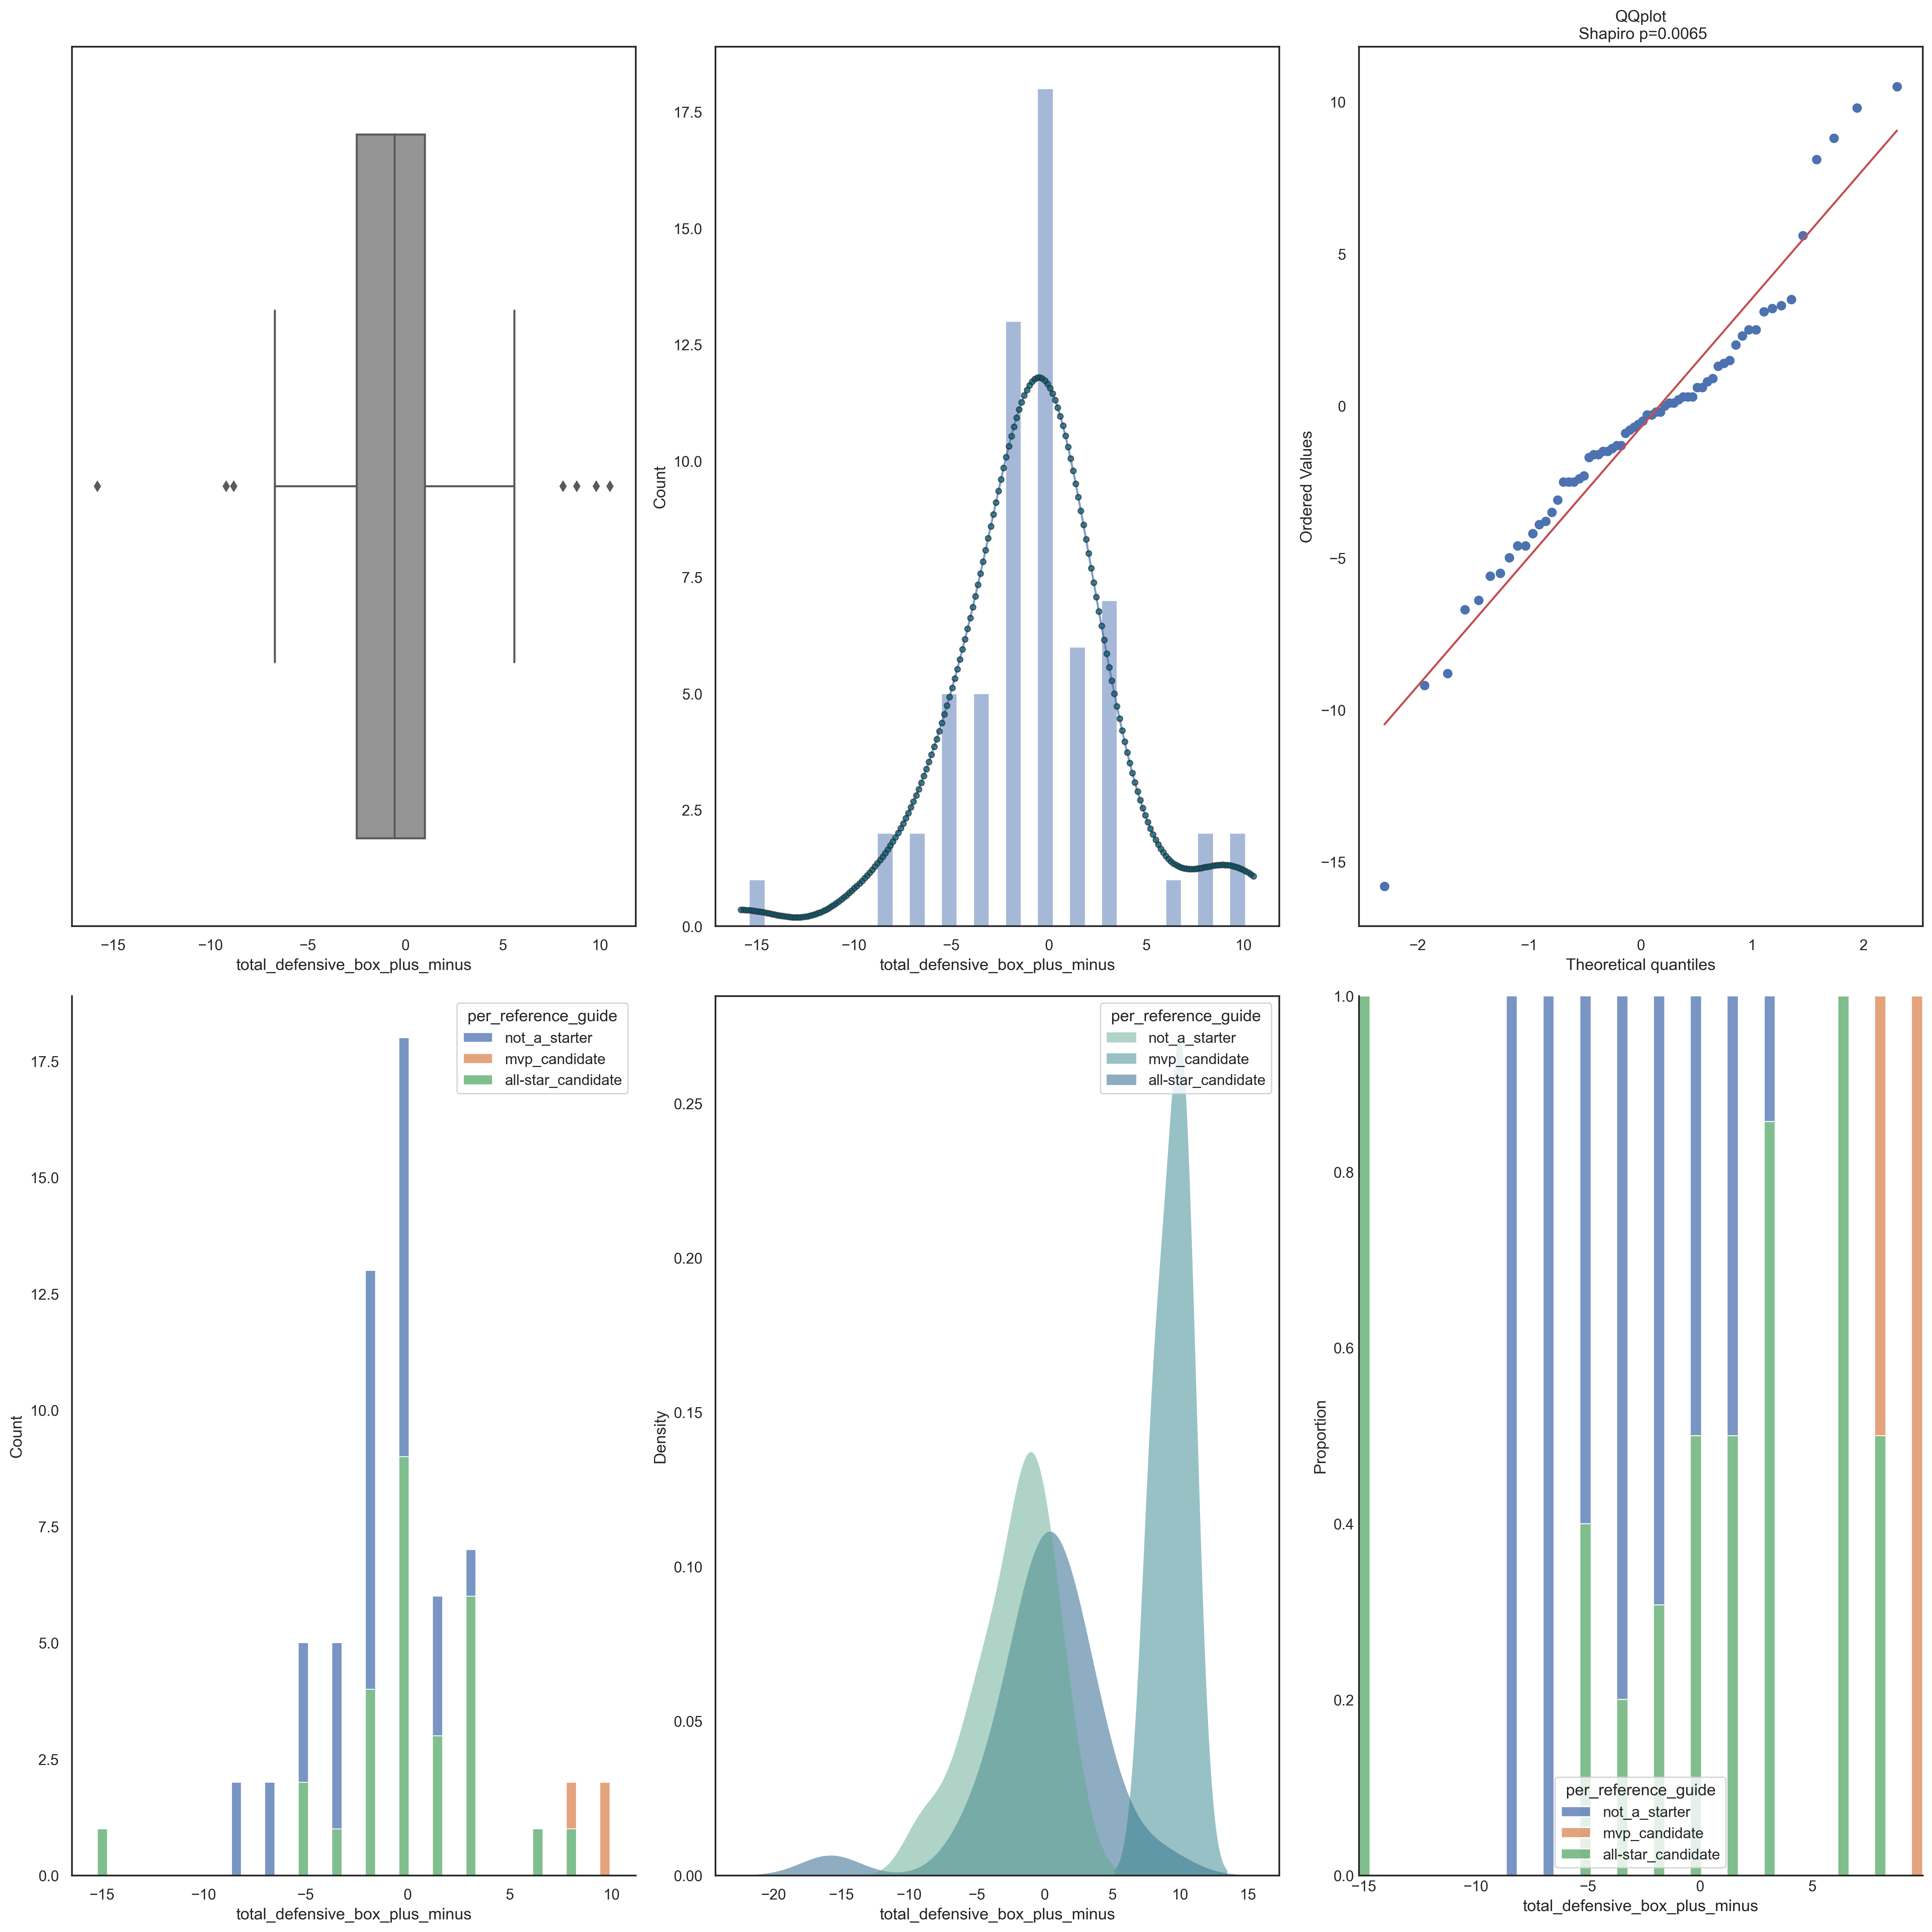

In [290]:
util.continuous_vs_binary(BestPicks_df ,'total_defensive_box_plus_minus' , 'per_reference_guide')

In [291]:
import importlib
importlib.reload(util)

<module 'utilities' from 'd:\\Quera Bootcamp\\Data Analysis\\Week 8\\3rd mini project\\Data-Analysis-Projects-2-Basketball\\utilities.py'>

c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\bashir rayaneh\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\bashir rayaneh\miniconda3\envs\quera

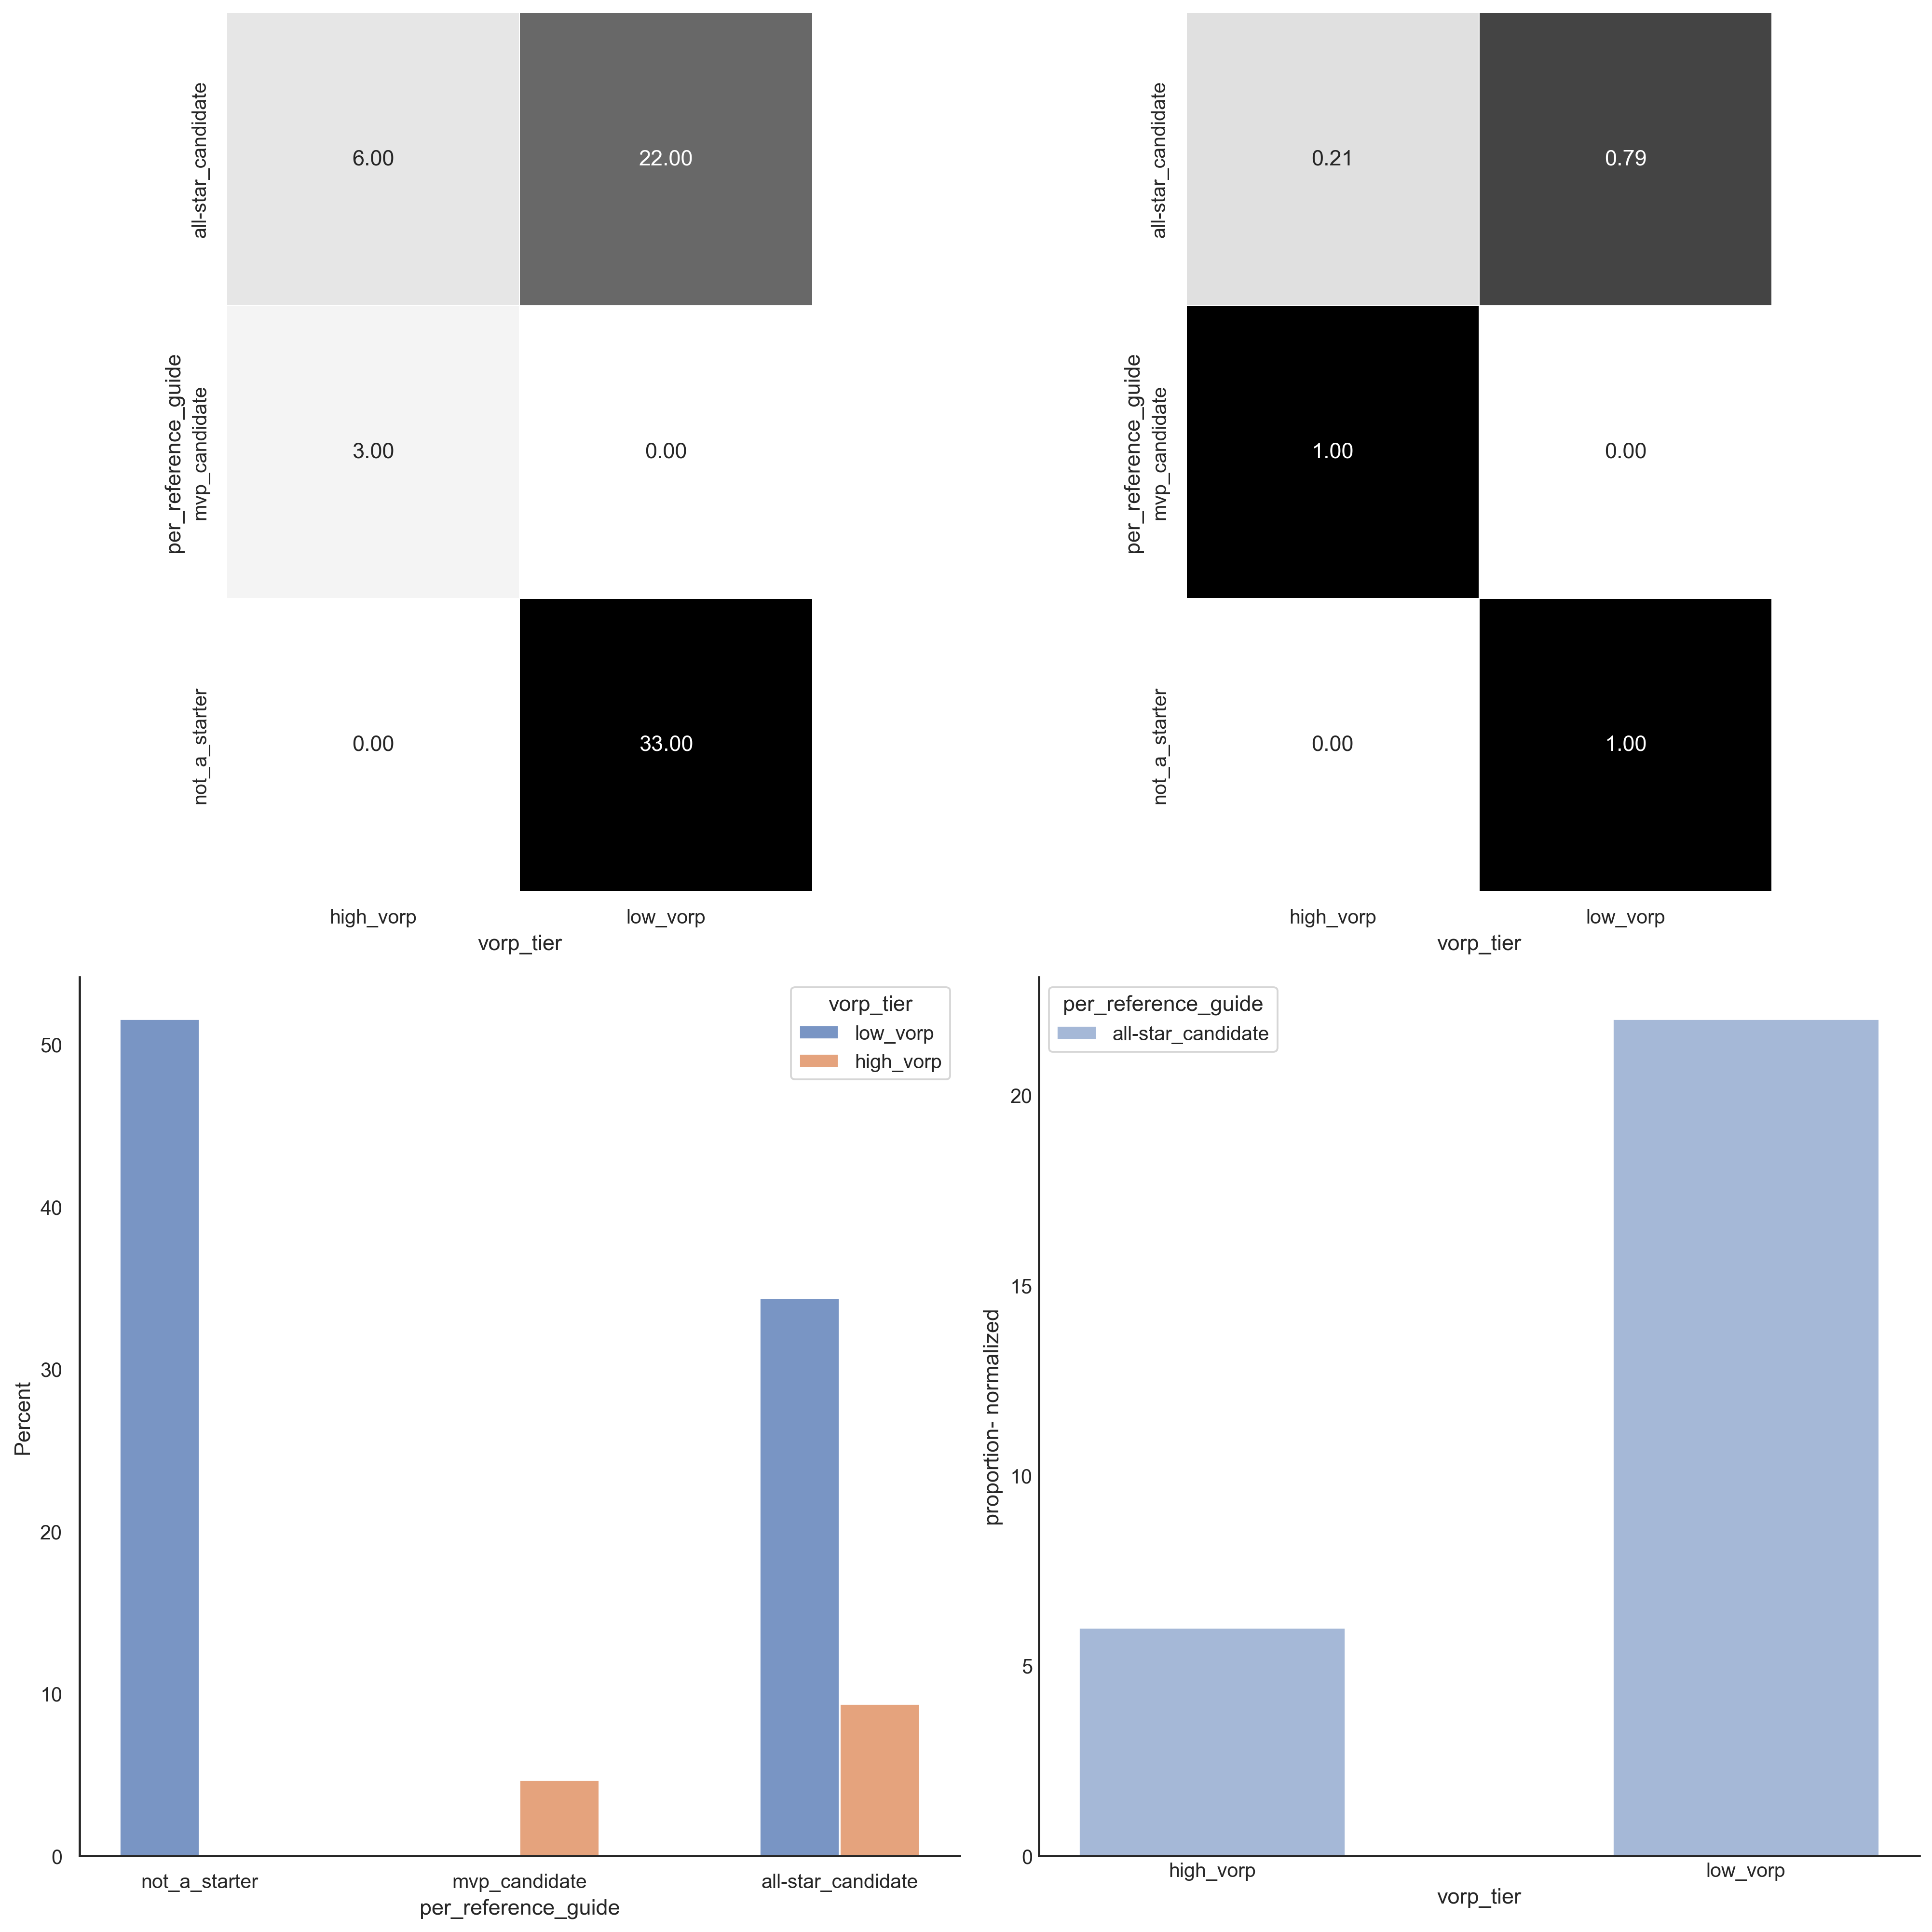

In [292]:
util.vorp_vs_eff('per_reference_guide' , 'vorp_tier' , BestPicks_df)

### Tests

First let's check if top 5 picks are really more efficient players

In [293]:
stats.ttest_ind(BestPicks_df[BestPicks_df['Top5_picks']==1]['average_efficiency_rate'] , BestPicks_df[BestPicks_df['Top5_picks']==0]['average_efficiency_rate'])

TtestResult(statistic=2.315295916660762, pvalue=0.023920423937533183, df=62.0)

Are they better defensive players too?

In [294]:
stats.mannwhitneyu(BestPicks_df[BestPicks_df['Top5_picks']==1]['total_defensive_box_plus_minus'] , BestPicks_df[BestPicks_df['Top5_picks']==0]['total_defensive_box_plus_minus'])

MannwhitneyuResult(statistic=635.5, pvalue=0.01445138806987955)

## Nominates List
Here is three list of player who are nominate for trade based on their efficiency and their performance in deffensive and offensive situations

In [295]:
Last_nominates=BestPicks_df[(BestPicks_df['per_reference_guide'] != 'not_a_starter') & (BestPicks_df['Top5_picks'] ==1)]

Last_nominates.reset_index(inplace=True)

Last_nominates=Last_nominates.drop('index' , axis=1)

In [296]:
Last_nominates

,player_id,player_name,age,experience,draft_overall_pick_rank,triple_doubles,average_efficiency_rate,total_win_shares,average_rebound_percentage,average_assist_percentage,average_steal_percentage,average_block_percentage,total_offensive_box_plus_minus,total_defensive_box_plus_minus,total_value_over_replacement_player,Top5_picks,vorp_tier,age_group,defense_tier,per_reference_guide
0,doncilu01,luka doncic,26.0,7.0,3.0,82.0,25.50,57.1,13.56,41.44,1.76,1.14,44.9,8.1,38.3,1.0,high_vorp,20-30,bad,mvp_candidate
1,jamesle01,lebron james,41.0,22.0,1.0,49.0,24.54,51.9,12.30,38.89,1.56,1.57,41.7,8.8,34.0,1.0,high_vorp,30-40,bad,all-star_candidate
2,hardeja01,james harden,36.0,16.0,3.0,40.0,23.95,59.6,10.05,38.42,1.98,1.83,34.7,5.6,32.2,1.0,high_vorp,30-40,bad,all-star_candidate
3,moranja01,ja morant,26.0,6.0,2.0,12.0,20.22,23.2,7.78,35.98,1.56,0.76,17.2,-3.1,11.4,1.0,low_vorp,20-30,great,all-star_candidate
4,duranke01,kevin durant,37.0,17.0,2.0,8.0,23.62,40.2,10.06,24.32,1.08,2.88,25.7,1.4,21.1,1.0,high_vorp,30-40,bad,all-star_candidate
5,embiijo01,joel embiid,31.0,9.0,3.0,7.0,29.82,55.3,19.43,21.72,1.45,4.18,36.5,10.5,27.5,1.0,high_vorp,30-40,bad,mvp_candidate
6,tatumja01,jayson tatum,27.0,8.0,3.0,4.0,20.90,58.4,11.87,19.26,1.56,1.66,25.3,3.2,27.3,1.0,high_vorp,20-30,bad,all-star_candidate
7,davisan02,anthony davis,32.0,13.0,1.0,3.0,27.52,48.1,18.50,16.18,1.80,5.76,24.5,9.8,22.8,1.0,high_vorp,30-40,bad,mvp_candidate
8,youngtr01,trae young,27.0,7.0,5.0,3.0,21.41,43.4,5.51,44.61,1.44,0.39,34.4,-15.8,19.1,1.0,low_vorp,20-30,great,all-star_candidate
9,griffbl01,blake griffin,36.0,NaN,1.0,2.0,21.00,8.0,11.80,27.10,1.00,0.90,4.9,0.2,4.7,1.0,low_vorp,30-40,bad,all-star_candidate


In [297]:
Defensive_nominates=BestPicks_df[(BestPicks_df['per_reference_guide'] != 'not_a_starter') & (BestPicks_df['Top5_picks'] ==1) & (BestPicks_df['defense_tier'] == 'great')]

Defensive_nominates.reset_index(inplace=True)

Defensive_nominates=Defensive_nominates.drop('index' , axis=1)


In [298]:
Defensive_nominates

,player_id,player_name,age,experience,draft_overall_pick_rank,triple_doubles,average_efficiency_rate,total_win_shares,average_rebound_percentage,average_assist_percentage,average_steal_percentage,average_block_percentage,total_offensive_box_plus_minus,total_defensive_box_plus_minus,total_value_over_replacement_player,Top5_picks,vorp_tier,age_group,defense_tier,per_reference_guide
0,moranja01,ja morant,26.0,6.0,2.0,12.0,20.22,23.2,7.78,35.98,1.56,0.76,17.2,-3.1,11.4,1.0,low_vorp,20-30,great,all-star_candidate
1,youngtr01,trae young,27.0,7.0,5.0,3.0,21.41,43.4,5.51,44.61,1.44,0.39,34.4,-15.8,19.1,1.0,low_vorp,20-30,great,all-star_candidate
2,bealbr01,bradley beal,32.0,13.0,3.0,2.0,22.23,18.6,6.93,24.97,1.67,1.17,13.9,-4.6,9.1,1.0,low_vorp,30-40,great,all-star_candidate
3,valanjo01,jonas valančiūnas,33.0,13.0,5.0,1.0,22.60,22.1,22.23,11.63,0.90,3.03,7.3,-0.2,6.4,1.0,low_vorp,30-40,great,all-star_candidate
4,irvinky01,kyrie irving,33.0,14.0,1.0,1.0,22.58,35.4,7.66,26.66,1.80,1.42,25.2,-0.2,18.3,1.0,low_vorp,30-40,great,all-star_candidate
5,aldrila01,lamarcus aldridge,40.0,NaN,2.0,0.0,22.90,9.3,15.10,11.60,0.80,3.40,2.4,-0.6,2.6,1.0,low_vorp,30-40,great,all-star_candidate


In [299]:
offensive_nominates=BestPicks_df[(BestPicks_df['per_reference_guide'] != 'not_a_starter') & (BestPicks_df['Top5_picks'] ==1) & (BestPicks_df['vorp_tier'] == 'high_vorp')]

offensive_nominates.reset_index(inplace=True)

offensive_nominates=offensive_nominates.drop('index' , axis=1)

In [300]:
offensive_nominates

,player_id,player_name,age,experience,draft_overall_pick_rank,triple_doubles,average_efficiency_rate,total_win_shares,average_rebound_percentage,average_assist_percentage,average_steal_percentage,average_block_percentage,total_offensive_box_plus_minus,total_defensive_box_plus_minus,total_value_over_replacement_player,Top5_picks,vorp_tier,age_group,defense_tier,per_reference_guide
0,doncilu01,luka doncic,26.0,7.0,3.0,82.0,25.50,57.1,13.56,41.44,1.76,1.14,44.9,8.1,38.3,1.0,high_vorp,20-30,bad,mvp_candidate
1,jamesle01,lebron james,41.0,22.0,1.0,49.0,24.54,51.9,12.30,38.89,1.56,1.57,41.7,8.8,34.0,1.0,high_vorp,30-40,bad,all-star_candidate
2,hardeja01,james harden,36.0,16.0,3.0,40.0,23.95,59.6,10.05,38.42,1.98,1.83,34.7,5.6,32.2,1.0,high_vorp,30-40,bad,all-star_candidate
3,duranke01,kevin durant,37.0,17.0,2.0,8.0,23.62,40.2,10.06,24.32,1.08,2.88,25.7,1.4,21.1,1.0,high_vorp,30-40,bad,all-star_candidate
4,embiijo01,joel embiid,31.0,9.0,3.0,7.0,29.82,55.3,19.43,21.72,1.45,4.18,36.5,10.5,27.5,1.0,high_vorp,30-40,bad,mvp_candidate
5,tatumja01,jayson tatum,27.0,8.0,3.0,4.0,20.90,58.4,11.87,19.26,1.56,1.66,25.3,3.2,27.3,1.0,high_vorp,20-30,bad,all-star_candidate
6,davisan02,anthony davis,32.0,13.0,1.0,3.0,27.52,48.1,18.50,16.18,1.80,5.76,24.5,9.8,22.8,1.0,high_vorp,30-40,bad,mvp_candidate
